In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# 데이터 불러오기
df = pd.read_csv('/content/drive/MyDrive/abalone.csv')
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [3]:
#Sex 데이터는 딥러닝이 학습할 수 없는 문자 데이터이기에 숫자 형태로 변환
df = pd.get_dummies(df, columns=['Sex'], drop_first=True)

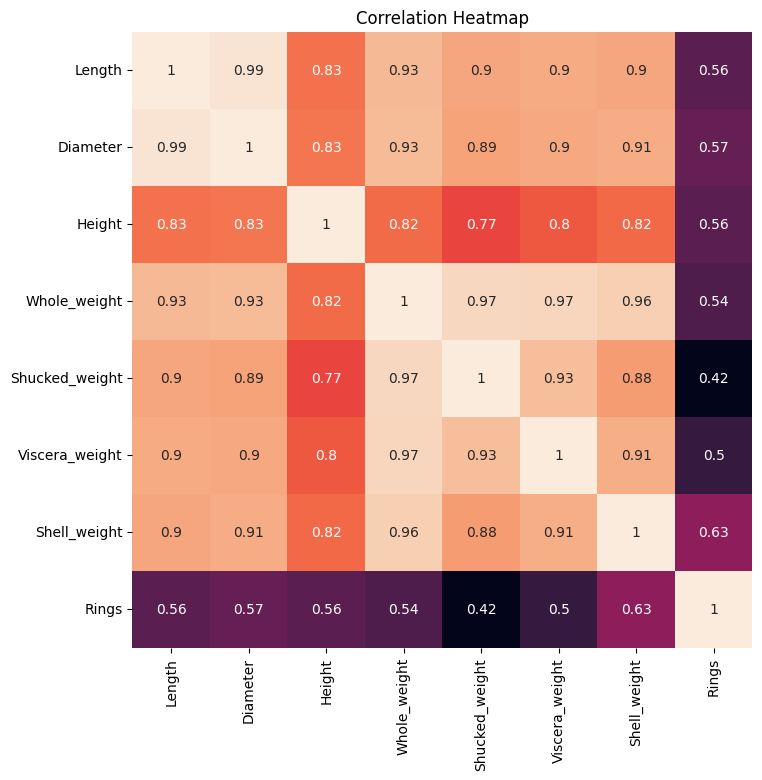

In [19]:
#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음
df_corr = df[[col for col in df.columns if ('Sex' not in col) and (col != 'id')]].corr()

plt.figure(figsize=(8,8))
sns.heatmap(df_corr, annot=True, cbar=False)
plt.title("Correlation Heatmap")
plt.show()

In [5]:
#딥러닝 입력을 위해 Numpy로 변환: .values
X = df.drop('Rings',axis=1).values
y = df['Rings'].values

In [6]:
X

array([[0, 0.455, 0.365, ..., 0.15, False, True],
       [1, 0.35, 0.265, ..., 0.07, False, True],
       [2, 0.53, 0.42, ..., 0.21, False, False],
       ...,
       [4174, 0.6, 0.475, ..., 0.308, False, True],
       [4175, 0.625, 0.485, ..., 0.296, False, False],
       [4176, 0.71, 0.555, ..., 0.495, False, True]], dtype=object)

In [7]:
y

array([15,  7,  9, ...,  9, 10, 12])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [9]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape,

((3341, 10), (3341,), (836, 10), (836,))

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
#Defining the model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,577 (17.88 KB)

 Trainable params: 4,577 (17.88 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#모델이 학습을 오래할 수록 데이터에 과적합할 가능성이 증가
#이를 방지하기 위해 손실을 기준으로 성능 개선이 되지 않는 다면 학습을 조기에 종료
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [13]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 75.0553 - mae: 7.7062 - val_loss: 31.8866 - val_mae: 4.6499
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 19.3995 - mae: 3.3391 - val_loss: 11.1744 - val_mae: 2.4455
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.9510 - mae: 2.1133 - val_loss: 6.4927 - val_mae: 1.7873
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.5867 - mae: 1.7938 - val_loss: 5.5722 - val_mae: 1.6587
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6565 - mae: 1.7076 - val_loss: 5.2400 - val_mae: 1.6250
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1780 - mae: 1.6582 - val_loss: 5.1191 - val_mae: 1.6184
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.8129 - mae: 1.6372 - val_loss: 5.0349 - val_mae: 1.6140
Epoch 8/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.5228 - mae: 1.6137 - val_loss: 4.9366 - val_mae: 1.5795
Epoch 9/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s

In [15]:
model.evaluate(X_test, y_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.0561 - mae: 1.4107


[4.056090354919434, 1.4106796979904175]

In [14]:
y_pred = model.predict(X_test).flatten()

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


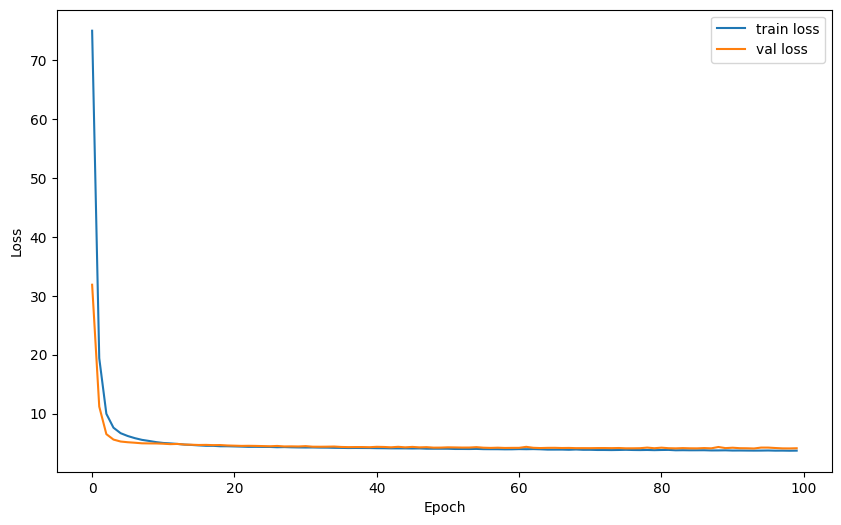

In [16]:
# loss 체크
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

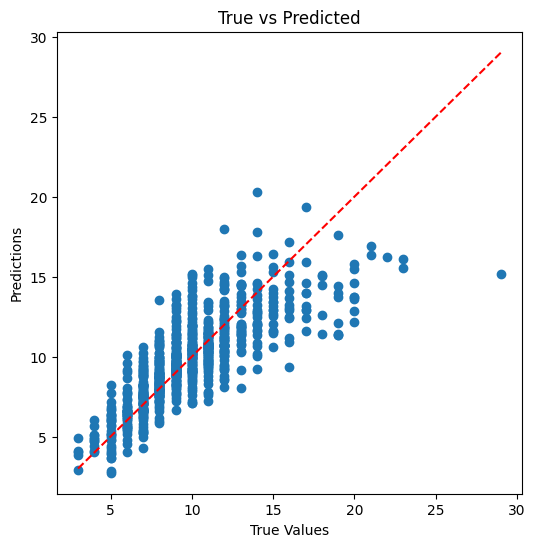

In [17]:
#실제값 vs 예측값 그래프 : 얼마나 맞췄는지
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # 완벽한 예측선
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True vs Predicted")
plt.show()

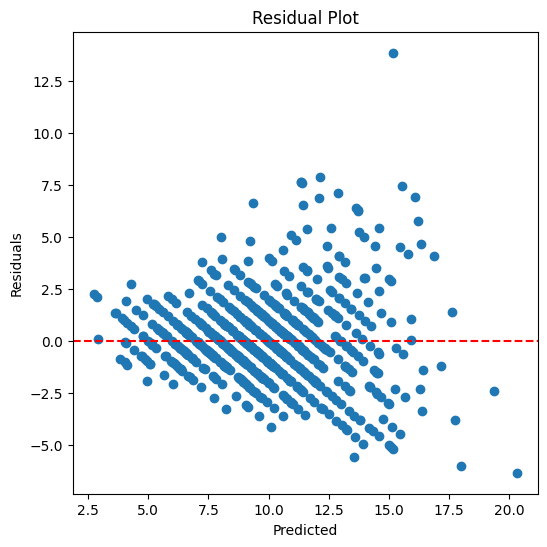

In [18]:
# 잔차 그래프 : 예측값과 실제값의 오차가 어떻게 분포하는지 확인
residuals = y_test - y_pred

plt.figure(figsize=(6,6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()